In [28]:
import pandas as pd
import numpy as np
import ast
import re
import sqlalchemy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
# from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

Загрузка датасетов для бейслайна (с преобразованием строк в списки)

In [29]:
df_rez = pd.read_csv('df_rez_new.csv')[['id', 'resume_title', 'text_clean', 'skills_list', 'experience_text']]
df_vac = pd.read_csv('df_vac_new.csv')[['id', 'vacancy_name', 'text_clean', 'skills_final', 'experience_years_min']]

In [30]:
df_vac.head()

,id,vacancy_name,text_clean,skills_final,experience_years_min
0,15,Аналитик данных / экономист инвестиционных про...,46 органов исполнительной власти 132 территори...,"['python', 'django', 'pandas', 'ms office (pow...",1.0
1,34,Data Engineer (разработчик DWH),задаем тренды технологиях ритейла x5 group рос...,"['sql', 'python', 'big data', 'apache airflow'...",3.0
2,92,Аналитик данных,центр компетенций бизнес аналитики финансового...,"['sql', 'python', 'hadoop', 'excel']",1.0
3,162,Data Engineer по построению DWH,ecofinance развивает внедряет продукты онлайн ...,"['etl', 'sql', 'dwh', 'apache kafka', 'debeziu...",3.0
4,65,Senior Data Scientist,создавай инновации атмосфере свободы расширяй ...,"['python', 'ml-библиотеки', 'sql']",1.0


In [31]:
def restore_list(value):
    return ast.literal_eval(value)

df_rez['skills_list'] = df_rez['skills_list'].apply(restore_list)
df_vac['skills_final'] = df_vac['skills_final'].apply(restore_list)

## Псевдоэталон (псевдоэталонная оценка)

Для данной задачи экспертная разметка релевантности пар «резюме-вакансия» отсутствовала. Поэтому для обучения и оценки моделей была сформирована псевдоэталонная оценка, основанная на структурированных признаках: соответствии опыта кандидата требованиям вакансии и совпадении навыков.

Для данной задачи был использован следующий метод:

Для расчета score по опыту работы
$$
exp\_score =
\begin{cases}
1, & \text{если } resume\_exp \ge vacancy\_exp \\
\dfrac{resume\_exp}{vacancy\_exp}, & \text{если } resume\_exp < vacancy\_exp
\end{cases}
$$

При расчете score по навыкам:
$$
skill\_score =
\frac{|resume\_skills \cap vacancy\_skills|}{|vacancy\_skills|}
$$

Итоговый score

$$
final\_score = 0.67 \cdot skill\_score + 0.33 \cdot exp\_score
$$

Больший вес был задан компоненте навыков, поскольку для задачи сопоставления резюме и вакансий совпадение профессиональных навыков является более информативным фактором, чем только соответствие минимальному требованию по опыту.

Далее для каждого резюме вакансии сортировались по значению final_score. Пары из верхней части распределения использовались как положительные примеры, а пары из нижней части — как отрицательные примеры для обучения моделей (см. далее).

Оценка опыта кандидата

In [32]:
def calc_exp_score(resume_exp, vacancy_exp):
    if pd.isna(resume_exp):
        resume_exp = 0.0
    if pd.isna(vacancy_exp):
        vacancy_exp = 0.0

    if vacancy_exp == 0:
        return 1.0

    if resume_exp >= vacancy_exp:
        return 1.0
    
    return resume_exp / vacancy_exp

Функция оценка скиллов кандидата

In [33]:
def calc_skill_score(resume_skills, vacancy_skills):
    matched_skills = len(set(resume_skills) & set(vacancy_skills))
    skill_score = matched_skills / len(vacancy_skills)
    return skill_score, matched_skills

Создание пар "резюме-вакансия"

In [34]:
df_pairs = df_rez.merge(df_vac, how='cross')

In [35]:
# Потом удалить
df_pairs = df_pairs[
    df_pairs["skills_list"].apply(lambda x: isinstance(x, list) and len(x) > 0) &
    df_pairs["skills_final"].apply(lambda x: isinstance(x, list) and len(x) > 0)
].copy()

Расчет score'ов

In [36]:
df_pairs[['skill_score', 'matched_skills']] = df_pairs.apply(
    lambda row: pd.Series(
        calc_skill_score(row['skills_list'], row['skills_final'])
    ),
    axis=1
)

In [37]:
df_pairs['exp_score'] = df_pairs.apply(
    lambda row: calc_exp_score(row['experience_text'], row['experience_years_min']),
    axis=1
)

In [38]:
df_pairs['pseudo_score'] = (
    0.67 * df_pairs['skill_score'] +
    0.33 * df_pairs['exp_score']
)

## Построение baseline

###  Эвристический подход

In [39]:
def tokenize_title(text):
    if pd.isna(text):
        return set()
    
    text = str(text).lower()
    tokens = re.findall(r"[а-яa-z0-9+#]+", text)

    stopwords = {
        "junior", "middle", "senior", "lead",
        "младший", "средний", "старший", "ведущий", "главный",
        "стажер", "стажёр",
        "специалист", "менеджер",
        "удаленно", "удалённо",
        "офис", "гибрид"
    }

    return set(tokens) - stopwords


def title_jaccard_score(resume_title, vacancy_title):
    resume_tokens = tokenize_title(resume_title)
    vacancy_tokens = tokenize_title(vacancy_title)
    
    if not resume_tokens or not vacancy_tokens:
        return 0
    
    return len(resume_tokens & vacancy_tokens) / len(resume_tokens | vacancy_tokens)


df_pairs["title_rule_score"] = df_pairs.apply(
    lambda row: title_jaccard_score(
        row["resume_title"],
        row["vacancy_name"]
    ),
    axis=1
)

In [40]:
title_rule_top5 = (
    df_pairs
    .sort_values(
        ["id_x", "title_rule_score"],
        ascending=[True, False]
    )
    .groupby("id_x")
    .head(5)
)

In [41]:
title_metrics = {
    "Модель": "По названиям",
    "Pseudo@5": title_rule_top5["pseudo_score"].mean(),
    "Skill@5": title_rule_top5["skill_score"].mean(),
    "Exp@5": title_rule_top5["exp_score"].mean(),
}
title_metrics

{'Модель': 'По названиям',
 'Pseudo@5': np.float64(0.5117812695138704),
 'Skill@5': np.float64(0.2810372116726089),
 'Exp@5': np.float64(0.980261629373401)}

### TF-IDF + Логистическая регрессия

In [42]:
train_resume_ids, test_resume_ids = train_test_split(
    df_rez['id'],
    test_size=0.2,
    random_state=42
)

train_pairs = df_pairs[df_pairs['id_x'].isin(train_resume_ids)].copy()
test_pairs = df_pairs[df_pairs['id_x'].isin(test_resume_ids)].copy()

print("Всего резюме:", df_rez['id'].nunique())
print("Train резюме:", len(train_resume_ids))
print("Test резюме:", len(test_resume_ids))
print("Train pairs:", train_pairs.shape)
print("Test pairs:", test_pairs.shape)

Всего резюме: 9347
Train резюме: 7477
Test резюме: 1870
Train pairs: (10127304, 15)
Test pairs: (2528064, 15)


Формирование псевдотаргета

In [49]:
def make_logreg_data_by_percent(
    df_pairs,
    resume_ids,
    pos_pct=0.05,
    neg_pct=0.20
):
    source = df_pairs[df_pairs['id_x'].isin(resume_ids)].copy()

    source['rank_pct'] = (
        source
        .groupby('id_x')['pseudo_score']
        .rank(pct=True, ascending=False)
    )

    logreg_data = source[
        (source['rank_pct'] <= pos_pct) |
        (source['rank_pct'] >= 1 - neg_pct)
    ].copy()

    logreg_data['target'] = (
        logreg_data['rank_pct'] <= pos_pct
    ).astype(int)

    return logreg_data

In [50]:
train_logreg = make_logreg_data_by_percent(
    df_pairs=df_pairs,
    resume_ids=train_resume_ids,
    pos_pct=0.05,
    neg_pct=0.20
)
train_logreg['target'].value_counts(normalize=True)

target
0    0.779998
1    0.220002
Name: proportion, dtype: float64

In [51]:
print('Размер train_logreg:', train_logreg.shape)
train_logreg['target'].value_counts()

Размер train_logreg: (2366820, 17)


target
0    1846116
1     520704
Name: count, dtype: int64

In [52]:
train_logreg[[
    'id_x',
    'id_y',
    'resume_title',
    'vacancy_name',
    'pseudo_score',
    'rank_pct',
    'target'
]].head(10)

,id_x,id_y,resume_title,vacancy_name,pseudo_score,rank_pct,target
1393,3,162,Аналитик данных,Data Engineer по построению DWH,0.383600,0.922515,0
1397,3,88,Аналитик данных,Data Scientist в команду рисков МСФО,1.000000,0.031798,1
1416,3,427,Аналитик данных,"Старший Data Scientist, Эффективность рекламы",0.413750,0.863304,0
1417,3,428,Аналитик данных,Data Scientist риск-модели,1.000000,0.031798,1
1420,3,438,Аналитик данных,Product/data analyst,1.000000,0.031798,1
1421,3,457,Аналитик данных,Data Scientist,0.404444,0.883041,0
1424,3,547,Аналитик данных,Аналитик данных,1.000000,0.031798,1
1425,3,2641,Аналитик данных,Data Engineer,0.397000,0.904605,0
1426,3,568,Аналитик данных,Аналитик данных по работе с маркетплейсами (ст...,0.330000,0.971857,0
1427,3,572,Аналитик данных,Bi-аналитик PowerBI,0.330000,0.971857,0


In [55]:
train_logreg = make_logreg_data_by_percent(
    df_pairs=df_pairs,
    resume_ids=train_resume_ids,
    pos_pct=0.05,
    neg_pct=0.20
)

train_logreg.shape

(2366820, 17)

In [56]:
train_logreg['target'].value_counts(normalize=True)

target
0    0.779998
1    0.220002
Name: proportion, dtype: float64

In [57]:
train_logreg['pair_text'] = (
    train_logreg['text_clean_x'].fillna('') + ' [sep] ' + train_logreg['text_clean_y'].fillna('')
)

train_logreg[['id_x', 'id_y', 'target', 'pair_text']].head()

,id_x,id_y,target,pair_text
1393,3,162,0,2025 termoland услуги населения... аналитик да...
1397,3,88,1,2025 termoland услуги населения... аналитик да...
1416,3,427,0,2025 termoland услуги населения... аналитик да...
1417,3,428,1,2025 termoland услуги населения... аналитик да...
1420,3,438,1,2025 termoland услуги населения... аналитик да...


In [58]:
tfidf_logreg = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.9
)

X_train = tfidf_logreg.fit_transform(train_logreg['pair_text'])
y_train = train_logreg['target']

X_train.shape, y_train.shape

((2366820, 20000), (2366820,))

In [59]:
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='liblinear'
)

logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [60]:
test_pairs = df_pairs[df_pairs['id_x'].isin(test_resume_ids)].copy()

test_pairs['pair_text'] = (
    test_pairs['text_clean_x'].fillna('') +
    ' [SEP] ' +
    test_pairs['text_clean_y'].fillna('')
)


test_pairs.shape

(2528064, 16)

Рассчет model_score, формирование top-5

In [61]:
X_test = tfidf_logreg.transform(test_pairs['pair_text'])

test_pairs['model_score'] = logreg.predict_proba(X_test)[:, 1]

test_pairs[['id_x', 'id_y', 'model_score', 'pseudo_score']].head()

,id_x,id_y,model_score,pseudo_score
0,2,15,0.311479,0.521429
1,2,34,0.042788,0.377857
2,2,92,0.728286,0.497500
3,2,162,0.001581,0.383600
4,2,65,0.157961,0.553333


In [62]:
logreg_top_matches = (
    test_pairs
    .sort_values(['id_x', 'model_score'], ascending=[True, False])
    .groupby('id_x')
    .head(5)
    .copy()
)

logreg_top_matches['rank'] = (
    logreg_top_matches
    .groupby('id_x')
    .cumcount() + 1
)

logreg_top_matches = logreg_top_matches.rename(columns={
    'id_x': 'resume_id',
    'id_y': 'vacancy_id'
})

logreg_top_matches = logreg_top_matches[[
    'resume_id',
    'resume_title',
    'vacancy_id',
    'vacancy_name',
    'rank',
    'model_score',
    'skill_score',
    'exp_score',
    'pseudo_score'
]]

logreg_top_matches.head()

,resume_id,resume_title,vacancy_id,vacancy_name,rank,model_score,skill_score,exp_score,pseudo_score
1017,2,Аналитик данных,12590,Senior Data Analyst,1,0.999481,0.5,1.0,0.665
1374,2,Аналитик данных,16725,Junior Data Analyst,2,0.999421,0.5,1.0,0.665
1383,2,Аналитик данных,16751,Младший аналитик данных,3,0.999421,0.5,1.0,0.665
1386,2,Аналитик данных,16759,Стажер Data Engineer,4,0.999231,0.5,1.0,0.665
769,2,Аналитик данных,9951,Продуктовый аналитик в fintech-команду сервиса...,5,0.999062,0.5,1.0,0.665


Метрики модели

In [63]:
logreg_metrics = {
    'model': 'TF-IDF + LogisticRegression',
    'Mean Pseudo Score@5': logreg_top_matches['pseudo_score'].mean(),
    'Mean Skill Score@5': logreg_top_matches['skill_score'].mean(),
    'Mean Exp Score@5': logreg_top_matches['exp_score'].mean(),
}
logreg_metrics_table = pd.DataFrame([logreg_metrics])
logreg_metrics_table

,model,Mean Pseudo Score@5,Mean Skill Score@5,Mean Exp Score@5
0,TF-IDF + LogisticRegression,0.782641,0.683442,0.984046


### Альтернативная модель: Embeddings + LogisticRegression

На следующем этапе была проверена альтернативная модель, основанная на эмбеддинговом представлении текстов. В отличие от TF-IDF, который учитывает лексические совпадения между текстами, эмбеддинги позволяют представить резюме и вакансии в виде плотных векторов, отражающих их смысловое содержание.

Для каждой пары «резюме-вакансия» сформированы признаки на основе эмбеддингов. Полученные признаки передавались в модель LogisticRegression, которая предсказывала вероятность принадлежности пары к классу релевантных.

In [66]:
emb_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)
resume_embeddings = emb_model.encode(
    df_rez["text_clean"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)
vacancy_embeddings = emb_model.encode(
    df_vac["text_clean"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches: 100%|██████████| 44/44 [00:27<00:00,  1.62it/s]


Для пары резюме-вакансия признаки формируются как абсолютная разность и покомпонентное произведение эмбеддингов.

In [67]:
def make_pair_embedding_features(resume_emb, vacancy_emb):
    return np.concatenate([
        np.abs(resume_emb - vacancy_emb),
        resume_emb * vacancy_emb
    ])

In [68]:
resume_id_to_idx = {
    resume_id: idx
    for idx, resume_id in enumerate(df_rez["id"])
}
vacancy_id_to_idx = {
    vacancy_id: idx
    for idx, vacancy_id in enumerate(df_vac["id"])
}
X_train_emb = []
for _, row in train_logreg.iterrows():
    r_idx = resume_id_to_idx[row["id_x"]]
    v_idx = vacancy_id_to_idx[row["id_y"]]

    features = make_pair_embedding_features(
        resume_embeddings[r_idx],
        vacancy_embeddings[v_idx]
    )
    X_train_emb.append(features)
X_train_emb = np.vstack(X_train_emb)
y_train_emb = train_logreg["target"].values

X_train_emb.shape, y_train_emb.shape

((2366820, 768), (2366820,))

In [69]:
emb_logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    )
)
emb_logreg.fit(X_train_emb, y_train_emb)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [70]:
import gc
gc.collect()

36696

С учетом размера test_pairs выполнено предсказание батчами

In [71]:
def make_embedding_features_for_pairs(pairs_df):
    X = []
    for _, row in pairs_df.iterrows():
        r_idx = resume_id_to_idx[row["id_x"]]
        v_idx = vacancy_id_to_idx[row["id_y"]]
        features = make_pair_embedding_features(
            resume_embeddings[r_idx],
            vacancy_embeddings[v_idx]
        )
        X.append(features)
    return np.vstack(X).astype("float32")


batch_size = 10_000
scores = np.zeros(len(test_pairs), dtype="float32")

for start in range(0, len(test_pairs), batch_size):
    end = min(start + batch_size, len(test_pairs))
    batch = test_pairs.iloc[start:end]
    X_batch = make_embedding_features_for_pairs(batch)
    scores[start:end] = emb_logreg.predict_proba(X_batch)[:, 1]
    del X_batch
    gc.collect()
    print(f"Обработано {end} / {len(test_pairs)}")

Обработано 10000 / 2528064
Обработано 20000 / 2528064
Обработано 30000 / 2528064
Обработано 40000 / 2528064
Обработано 50000 / 2528064
Обработано 60000 / 2528064
Обработано 70000 / 2528064
Обработано 80000 / 2528064
Обработано 90000 / 2528064
Обработано 100000 / 2528064
Обработано 110000 / 2528064
Обработано 120000 / 2528064
Обработано 130000 / 2528064
Обработано 140000 / 2528064
Обработано 150000 / 2528064
Обработано 160000 / 2528064
Обработано 170000 / 2528064
Обработано 180000 / 2528064
Обработано 190000 / 2528064
Обработано 200000 / 2528064
Обработано 210000 / 2528064
Обработано 220000 / 2528064
Обработано 230000 / 2528064
Обработано 240000 / 2528064
Обработано 250000 / 2528064
Обработано 260000 / 2528064
Обработано 270000 / 2528064
Обработано 280000 / 2528064
Обработано 290000 / 2528064
Обработано 300000 / 2528064
Обработано 310000 / 2528064
Обработано 320000 / 2528064
Обработано 330000 / 2528064
Обработано 340000 / 2528064
Обработано 350000 / 2528064
Обработано 360000 / 2528064
О

In [72]:
test_pairs = test_pairs.copy()
test_pairs["emb_logreg_score"] = scores

In [73]:
test_pairs[["id_x", "id_y", "emb_logreg_score"]].head()

,id_x,id_y,emb_logreg_score
0,2,15,0.050005
1,2,34,0.415385
2,2,92,0.160061
3,2,162,0.030190
4,2,65,0.325167


In [74]:
emb_logreg_top_matches = (
    test_pairs
    .sort_values(["id_x", "emb_logreg_score"], ascending=[True, False])
    .groupby("id_x")
    .head(5)
    .reset_index(drop=True)
)

In [75]:
emb_logreg_metrics = {
    "model": "Embeddings + LogisticRegression",
    "Mean Pseudo Score@5": emb_logreg_top_matches["pseudo_score"].mean(),
    "Mean Skill Score@5": emb_logreg_top_matches["skill_score"].mean(),
    "Mean Exp Score@5": emb_logreg_top_matches["exp_score"].mean(),
}

emb_logreg_metrics

{'model': 'Embeddings + LogisticRegression',
 'Mean Pseudo Score@5': np.float64(0.6644448245240385),
 'Mean Skill Score@5': np.float64(0.5111602746982807),
 'Mean Exp Score@5': np.float64(0.9756589105339105)}

In [76]:
emb_logreg_metrics = {
    "model": "Embeddings + LogisticRegression",
    "Mean Pseudo Score@5": emb_logreg_top_matches["pseudo_score"].mean(),
    "Mean Skill Score@5": emb_logreg_top_matches["skill_score"].mean(),
    "Mean Exp Score@5": emb_logreg_top_matches["exp_score"].mean(),
}
emb_logreg_metrics_table = pd.DataFrame([emb_logreg_metrics])
emb_logreg_metrics_table.round(3)

,model,Mean Pseudo Score@5,Mean Skill Score@5,Mean Exp Score@5
0,Embeddings + LogisticRegression,0.664,0.511,0.976


In [77]:
ranking_comparison = pd.DataFrame([
    logreg_metrics,
    emb_logreg_metrics
])
ranking_comparison.round(3)

,model,Mean Pseudo Score@5,Mean Skill Score@5,Mean Exp Score@5
0,TF-IDF + LogisticRegression,0.783,0.683,0.984
1,Embeddings + LogisticRegression,0.664,0.511,0.976


In [78]:
test_pairs[
    ["id_x", "id_y", "pseudo_score", "model_score", "emb_logreg_score"]
].head()

,id_x,id_y,pseudo_score,model_score,emb_logreg_score
0,2,15,0.521429,0.311479,0.050005
1,2,34,0.377857,0.042788,0.415385
2,2,92,0.497500,0.728286,0.160061
3,2,162,0.383600,0.001581,0.030190
4,2,65,0.553333,0.157961,0.325167


In [79]:
def make_classification_test_by_percent(df_pairs, pos_pct=0.05, neg_pct=0.20):
    df = df_pairs.copy()

    df["rank_pct"] = (
        df.groupby("id_x")["pseudo_score"]
        .rank(pct=True, ascending=False)
    )

    pos_mask = df["rank_pct"] <= pos_pct
    neg_mask = df["rank_pct"] >= 1 - neg_pct

    df = df[pos_mask | neg_mask].copy()

    df["target"] = pos_mask[pos_mask | neg_mask].astype(int)

    return df

In [80]:
test_classification = make_classification_test_by_percent(
    test_pairs,
    pos_pct=0.05,
    neg_pct=0.20
)

test_classification["target"].value_counts(normalize=True)

target
0    0.78275
1    0.21725
Name: proportion, dtype: float64

## Оценка качества

In [81]:
def calculate_classification_metrics(y_true, y_score, model_name, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        "model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
    }

In [82]:
y_true = test_classification["target"].values

tfidf_cls_metrics = calculate_classification_metrics(
    y_true=y_true,
    y_score=test_classification["model_score"].values,
    model_name="TF-IDF + LogisticRegression",
    threshold=0.5
)

emb_cls_metrics = calculate_classification_metrics(
    y_true=y_true,
    y_score=test_classification["emb_logreg_score"].values,
    model_name="Embeddings + LogisticRegression",
    threshold=0.5
)

classification_comparison = pd.DataFrame([
    tfidf_cls_metrics,
    emb_cls_metrics
])

classification_comparison.round(3)

,model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,TF-IDF + LogisticRegression,0.952,0.844,0.958,0.897,0.990,0.965
1,Embeddings + LogisticRegression,0.782,0.499,0.790,0.611,0.862,0.658


In [83]:
def show_confusion_matrix(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    return pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )

In [84]:
show_confusion_matrix(
    y_true,
    test_classification["model_score"].values,
    threshold=0.5
)

,Predicted 0,Predicted 1
Actual 0,444037,23022
Actual 1,5413,124218


In [85]:
show_confusion_matrix(
    y_true,
    test_classification["emb_logreg_score"].values,
    threshold=0.5
)

,Predicted 0,Predicted 1
Actual 0,364118,102941
Actual 1,27280,102351


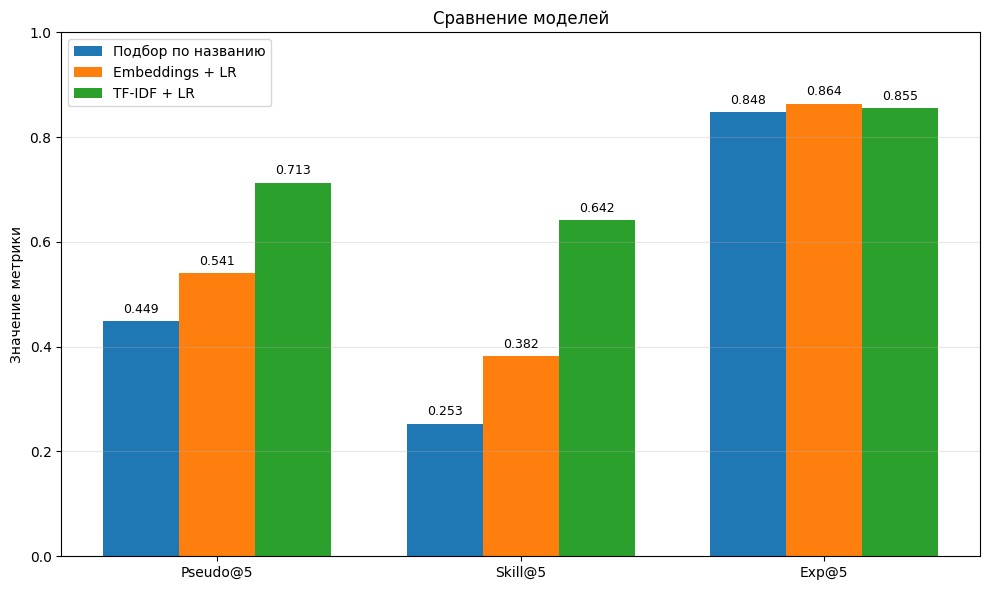

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.DataFrame([
        {
        "Модель": "Подбор по названию",
        "Pseudo@5": 0.449,
        "Skill@5": 0.253,
        "Exp@5": 0.848
    },

    {
        "Модель": "Embeddings + LR",
        "Pseudo@5": 0.541,
        "Skill@5": 0.382,
        "Exp@5": 0.864
    },

        {
        "Модель": "TF-IDF + LR",
        "Pseudo@5": 0.713,
        "Skill@5": 0.642,
        "Exp@5": 0.855
    }
])

metrics = ["Pseudo@5", "Skill@5", "Exp@5"]
models = results_df["Модель"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

for i, model in enumerate(models):
    values = results_df.loc[results_df["Модель"] == model, metrics].values.flatten()
    plt.bar(x + (i - 1) * width, values, width, label=model)

for i, model in enumerate(models):
    values = results_df.loc[results_df["Модель"] == model, metrics].values.flatten()
    for j, value in enumerate(values):
        plt.text(
            x[j] + (i - 1) * width,
            value + 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Значение метрики")
plt.title("Сравнение моделей")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Итоговый вывод

На данномэтапе была реализована экспериментальная проверка моделей для задачи сопоставления резюме и вакансий. Поскольку в исходных данных отсутствовала ручная разметка релевантных пар, была сформирована псевдоразметка на основе прикладных признаков соответствия: совпадения навыков и соответствия опыта работы.

Для каждой пары «резюме — вакансия» были рассчитаны следующие показатели:

- skill_score — доля навыков вакансии, которые присутствуют в резюме кандидата;
- exp_score — степень соответствия опыта кандидата минимальным требованиям вакансии;
- pseudo_score — итоговая псевдооценка соответствия пары, рассчитанная как взвешенная сумма skill_score и exp_score.

На основе pseudo_score был сформирован бинарный псевдотаргет: пары из верхней части ранжирования рассматривались как условно релевантные, а пары из нижней части — как условно нерелевантные. Средняя часть пар не использовалась при обучении, чтобы снизить влияние неоднозначных примеров.

В работе были сравнены две модели:

1. **TF-IDF + LogisticRegression** — модель на основе лексического представления объединенного текста резюме и вакансии.
2. **Embeddings + LogisticRegression** — модель на основе семантических векторных представлений текстов, полученных с помощью SentenceTransformer.

По результатам оценки в top-5 рекомендаций модель **TF-IDF + LogisticRegression** показала более высокое качество по ключевым метрикам:

- более высокое среднее значение Mean Pseudo Score@5;
- более высокое среднее совпадение навыков Mean Skill Score@5;
- сопоставимое качество по соответствию опыта Mean Exp Score@5.

Дополнительно модели были оценены как бинарные классификаторы с использованием классических ML-метрик: Accuracy, Precision, Recall, F1-score, ROC-AUC и PR-AUC. По этим метрикам модель **TF-IDF + LogisticRegression** также показала лучший результат по сравнению с моделью на эмбеддингах.

Таким образом, в рамках проведенного эксперимента наилучшей моделью является **TF-IDF + LogisticRegression**. 

Полученный результат можно объяснить тем, что в задаче сопоставления резюме и вакансий большое значение имеют точные лексические совпадения профессиональных терминов, технологий и навыков. Эмбеддинговая модель лучше отражает общий смысл текста, однако в данном эксперименте хуже приблизилась к псевдоразметке, построенной на основе навыков и опыта.

В качестве итоговой модели для дальнейшего использования в демонстрационном прототипе выбрана **TF-IDF + LogisticRegression**.